<a href="https://colab.research.google.com/github/Suvanga/ML_DL/blob/main/Starbucks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import os

if 'Final_Starbucks_Training_Data.csv' not in os.listdir():
    from google.colab import files
    uploaded = files.upload()

Saving Book3_converted.csv to Book3_converted (2).csv


In [12]:
print(df.columns)

Index(['Date', 'Hour', 'Day_of_Week', 'Is_Weekend', 'Is_Classes_In_Session',
       'Max', 'Snow_Inches', 'Total_Orders (Count)',
       'Total_Sales (Sum Check Amount)'],
      dtype='object')


In [15]:
import torch
import pandas as pd
from sklearn.model_selection import train_test_split

# 1. Setup device-agnostic code
# While Random Forest primarily runs on CPU, this is best practice for your ML pipeline
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Current device: {device}")

# 2. Load the combined dataset
# Note: Ensure the filename matches exactly what you uploaded
df = pd.read_csv('Book3_converted (2).csv')

# 3. Pre-processing: Convert Day_of_Week to numerical codes (0-6)
df['Day_of_Week'] = pd.Categorical(df['Day_of_Week'],
                                   categories=['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'],
                                   ordered=True).codes

# 4. Define Features (X) and Target (y)
# These are the columns we built in the previous step
X = df[['Hour', 'Day_of_Week', 'Is_Weekend', 'Is_Classes_In_Session', 'Max', 'Snow_Inches']]
y = df['Total_Orders (Count)']

# 5. Perform Train-Test Split
# We use 80% for training and 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("-" * 30)
print(f"✅ Data Preparation Complete")
print(f"Total Samples: {len(df)}")
print(f"Training Samples: {len(X_train)}")
print(f"Testing Samples: {len(X_test)}")

Current device: cpu
------------------------------
✅ Data Preparation Complete
Total Samples: 4748
Training Samples: 3798
Testing Samples: 950


Model R-squared: 0.45
Average Error: 11.19 orders per hour


/tmp/ipykernel_7067/2066952944.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances, y=importances.index, palette='viridis')


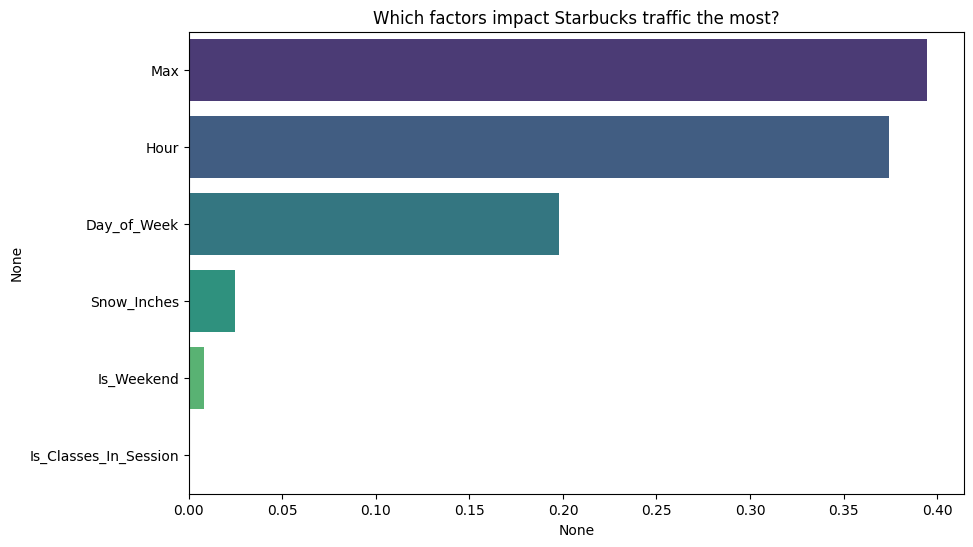

In [16]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# 5. Evaluate the Model
predictions = model.predict(X_test)
print(f"Model R-squared: {r2_score(y_test, predictions):.2f}")
print(f"Average Error: {mean_absolute_error(y_test, predictions):.2f} orders per hour")

# 6. Visualize Feature Importance
importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(10,6))
sns.barplot(x=importances, y=importances.index, palette='viridis')
plt.title('Which factors impact Starbucks traffic the most?')
plt.show()

In [17]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.impute import SimpleImputer
from sklearn.pipeline import make_pipeline

# Initialize the model with an imputer to handle NaNs
lr_model = make_pipeline(SimpleImputer(strategy='mean'), LinearRegression())

# Train the Linear Regression model
lr_model.fit(X_train, y_train)

# Predict and evaluate
lr_predictions = lr_model.predict(X_test)
print("--- Linear Regression Baseline ---")
print(f"Model R-squared: {r2_score(y_test, lr_predictions):.2f}")
print(f"Average Error: {mean_absolute_error(y_test, lr_predictions):.2f} orders per hour")


--- Linear Regression Baseline ---
Model R-squared: 0.13
Average Error: 15.98 orders per hour


In [23]:
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, r2_score

print("Training Decision Tree...")
dt_model = make_pipeline(SimpleImputer(strategy='mean'), DecisionTreeRegressor(random_state=42))
dt_model.fit(X_train, y_train)
dt_predictions = dt_model.predict(X_test)
print("--- Decision Tree ---")
print(f"Model R-squared: {r2_score(y_test, dt_predictions):.2f}")
print(f"Average Error: {mean_absolute_error(y_test, dt_predictions):.2f} orders per hour\n")

print("Training XGBoost...")
xgb_model = make_pipeline(SimpleImputer(strategy='mean'), XGBRegressor(n_estimators=100, random_state=42))
xgb_model.fit(X_train, y_train)
xgb_predictions = xgb_model.predict(X_test)
print("--- XGBoost ---")
print(f"Model R-squared: {r2_score(y_test, xgb_predictions):.2f}")
print(f"Average Error: {mean_absolute_error(y_test, xgb_predictions):.2f} orders per hour")

Training Decision Tree...
--- Decision Tree ---
Model R-squared: 0.25
Average Error: 12.76 orders per hour

Training XGBoost...
--- XGBoost ---
Model R-squared: 0.56
Average Error: 10.13 orders per hour


In [19]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBRegressor
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, r2_score

# Create a pipeline with imputation and the model
xgb_pipeline = make_pipeline(
    SimpleImputer(strategy='mean'),
    XGBRegressor(random_state=42)
)

# Define a grid of hyperparameters to search
# Note: using a relatively small grid so it runs quickly
param_grid = {
    'xgbregressor__n_estimators': [50, 100, 200],
    'xgbregressor__max_depth': [3, 5, 7],
    'xgbregressor__learning_rate': [0.01, 0.1, 0.2]
}

print("Starting hyperparameter tuning for XGBoost...")
grid_search = GridSearchCV(
    estimator=xgb_pipeline,
    param_grid=param_grid,
    cv=3,                 # 3-fold cross-validation
    scoring='neg_mean_absolute_error',
    n_jobs=-1,            # Use all available CPU cores
    verbose=1
)

# Fit the grid search to the data
grid_search.fit(X_train, y_train)

# Get the best model from the search
best_xgb_model = grid_search.best_estimator_

# Predict and evaluate with the best model
best_xgb_predictions = best_xgb_model.predict(X_test)

print(f"\nBest Parameters found: {grid_search.best_params_}")
print("--- Tuned XGBoost ---")
print(f"Model R-squared: {r2_score(y_test, best_xgb_predictions):.2f}")
print(f"Average Error: {mean_absolute_error(y_test, best_xgb_predictions):.2f} orders per hour")


Starting hyperparameter tuning for XGBoost...
Fitting 3 folds for each of 27 candidates, totalling 81 fits

Best Parameters found: {'xgbregressor__learning_rate': 0.2, 'xgbregressor__max_depth': 5, 'xgbregressor__n_estimators': 200}
--- Tuned XGBoost ---
Model R-squared: 0.57
Average Error: 10.12 orders per hour


In [24]:
import pandas as pd

# Create some hypothetical "new data" scenarios
# Features needed: Hour, Day_of_Week, Is_Weekend, Is_Classes_In_Session, Max, Snow_Inches
# Day_of_Week codes: 0=Mon, 1=Tue, 2=Wed, 3=Thu, 4=Fri, 5=Sat, 6=Sun
new_data = pd.DataFrame({
    'Hour': [8, 14, 10],                     # 8 AM, 2 PM, 10 AM
    'Day_of_Week': [0, 5, 2],                # Monday, Saturday, Wednesday
    'Is_Weekend': [0, 1, 0],                 # Weekday, Weekend, Weekday
    'Is_Classes_In_Session': [1, 0, 1],      # Yes, No, Yes
    'Max': [45.0, 75.0, 30.0],          # Cold, Warm, Freezing (Changed from Max_Temp to Max)
    'Snow_Inches': [0.0, 0.0, 2.5]           # No snow, No snow, Snowy
})

print("--- New Data Scenarios ---")
display(new_data)

# Use the tuned XGBoost model to make predictions
new_predictions = best_xgb_model.predict(new_data)

# Add predictions to the dataframe for easy viewing
# We round the predictions since we can't have fractional orders
new_data['Predicted_Total_Orders'] = new_predictions.round().astype(int)

print("\n--- Predictions ---")
display(new_data[['Hour', 'Day_of_Week', 'Is_Weekend', 'Max', 'Predicted_Total_Orders']])


--- New Data Scenarios ---


,Hour,Day_of_Week,Is_Weekend,Is_Classes_In_Session,Max,Snow_Inches
0,8,0,0,1,45.0,0.0
1,14,5,1,0,75.0,0.0
2,10,2,0,1,30.0,2.5



--- Predictions ---


,Hour,Day_of_Week,Is_Weekend,Max,Predicted_Total_Orders
0,8,0,0,45.0,25
1,14,5,1,75.0,4
2,10,2,0,30.0,51


In [25]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, r2_score

# Pipeline with imputation and Random Forest
rf_pipeline = make_pipeline(
    SimpleImputer(strategy='mean'),
    RandomForestRegressor(random_state=42)
)

# Define hyperparameter grid for Random Forest
# Setting n_estimators to 100 to simulate the requested '100 epochs'
rf_param_grid = {
    'randomforestregressor__n_estimators': [100],
    'randomforestregressor__max_depth': [None, 10, 20],
    'randomforestregressor__min_samples_split': [2, 5, 10]
}

print("Starting hyperparameter tuning for Random Forest...")
rf_grid_search = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=rf_param_grid,
    cv=3,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    verbose=1
)

# Fit the grid search to the data
rf_grid_search.fit(X_train, y_train)

# Get the best model and evaluate
best_rf_model = rf_grid_search.best_estimator_
best_rf_predictions = best_rf_model.predict(X_test)

print(f"\nBest Parameters found: {rf_grid_search.best_params_}")
print("--- Tuned Random Forest ---")
print(f"Model R-squared: {r2_score(y_test, best_rf_predictions):.2f}")
print(f"Average Error: {mean_absolute_error(y_test, best_rf_predictions):.2f} orders per hour")


Starting hyperparameter tuning for Random Forest...
Fitting 3 folds for each of 9 candidates, totalling 27 fits

Best Parameters found: {'randomforestregressor__max_depth': 20, 'randomforestregressor__min_samples_split': 10, 'randomforestregressor__n_estimators': 100}
--- Tuned Random Forest ---
Model R-squared: 0.53
Average Error: 10.56 orders per hour


### 1. Train-Test Split Analysis
Let's verify that our 80/20 split resulted in representative datasets by comparing the distribution of the target variable (`Total_Orders`) in both the training and testing sets.

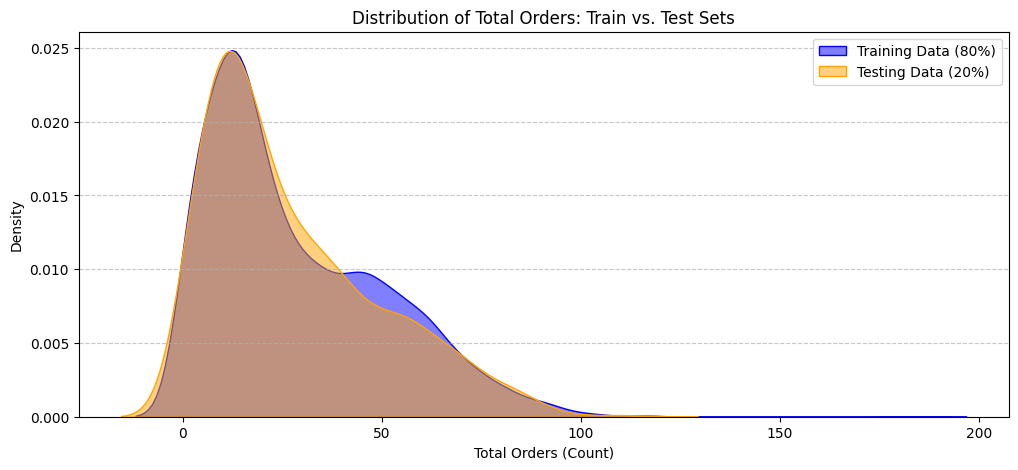

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set up the plot
plt.figure(figsize=(12, 5))

# Plot distribution for Training Data
sns.kdeplot(y_train, label='Training Data (80%)', fill=True, color='blue', alpha=0.5)

# Plot distribution for Testing Data
sns.kdeplot(y_test, label='Testing Data (20%)', fill=True, color='orange', alpha=0.5)

plt.title('Distribution of Total Orders: Train vs. Test Sets')
plt.xlabel('Total Orders (Count)')
plt.ylabel('Density')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### 2. Proper Training Scenario: Learning Curves
A proper training scenario involves checking if the model is actually learning or just memorizing the data. We use **Learning Curves** for this. If the training error and validation error converge at a good score, we have a well-fitted model. If there's a huge gap, it's overfitting.

Calculating learning curves for Tuned XGBoost (this may take a moment)...


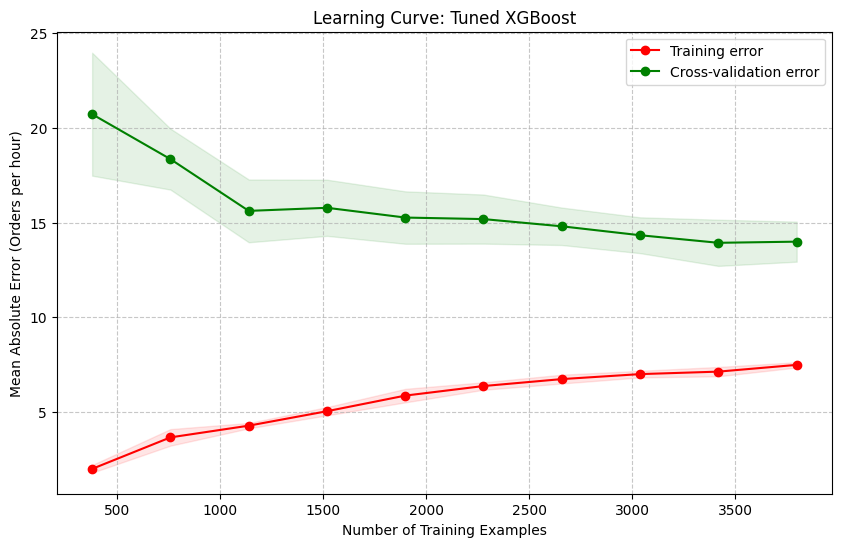

In [27]:
from sklearn.model_selection import learning_curve
import numpy as np

print("Calculating learning curves for Tuned XGBoost (this may take a moment)...")

# We use the best XGBoost pipeline we found earlier
train_sizes, train_scores, val_scores = learning_curve(
    best_xgb_model,
    X, y,
    cv=5, # 5-fold cross-validation
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10), # Test 10 different sizes of training data
    random_state=42
)

# Calculate mean and standard deviation for training and validation sets
train_scores_mean = -np.mean(train_scores, axis=1)
train_scores_std = np.std(train_scores, axis=1)
val_scores_mean = -np.mean(val_scores, axis=1)
val_scores_std = np.std(val_scores, axis=1)

# Plot learning curve
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_scores_mean, 'o-', color="r", label="Training error")
plt.plot(train_sizes, val_scores_mean, 'o-', color="g", label="Cross-validation error")

# Draw error bands
plt.fill_between(train_sizes, train_scores_mean - train_scores_std, train_scores_mean + train_scores_std, alpha=0.1, color="r")
plt.fill_between(train_sizes, val_scores_mean - val_scores_std, val_scores_mean + val_scores_std, alpha=0.1, color="g")

plt.title('Learning Curve: Tuned XGBoost')
plt.xlabel('Number of Training Examples')
plt.ylabel('Mean Absolute Error (Orders per hour)')
plt.legend(loc="best")
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### 3. Feature Engineering
Let's create some new features based on domain knowledge of a typical coffee shop to see if we can improve our model's predictive power.

In [29]:
import pandas as pd
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, r2_score

# Create a copy of the dataframe to avoid modifying the original safely
df_fe = df.copy()

# 1. Rush Hour Flag (e.g., 7 AM - 9 AM, 11 AM - 1 PM)
df_fe['Is_Rush_Hour'] = df_fe['Hour'].isin([7, 8, 9, 11, 12, 13]).astype(int)

# 2. Weekday Morning Routine (Weekday AND before 10 AM)
df_fe['Weekday_Morning'] = ((df_fe['Is_Weekend'] == 0) & (df_fe['Hour'] <= 10)).astype(int)

# 3. Extreme Weather Flag (Freezing temperatures or snowy)
df_fe['Extreme_Weather'] = ((df_fe['Max'] <= 32) | (df_fe['Snow_Inches'] >= 1.0)).astype(int)

# 4. Afternoon Slump (e.g., 2 PM - 4 PM)
df_fe['Afternoon_Slump'] = df_fe['Hour'].isin([14, 15, 16]).astype(int)

# Define new Features (X) and Target (y)
X_fe = df_fe[['Hour', 'Day_of_Week', 'Is_Weekend', 'Is_Classes_In_Session',
              'Max', 'Snow_Inches', 'Is_Rush_Hour', 'Weekday_Morning',
              'Extreme_Weather', 'Afternoon_Slump']]
y_fe = df_fe['Total_Orders (Count)']

# Perform Train-Test Split
X_train_fe, X_test_fe, y_train_fe, y_test_fe = train_test_split(X_fe, y_fe, test_size=0.2, random_state=42)

print("New features created successfully! Dataset shape:", X_fe.shape)
display(X_fe.head())

New features created successfully! Dataset shape: (4748, 10)


,Hour,Day_of_Week,Is_Weekend,Is_Classes_In_Session,Max,Snow_Inches,Is_Rush_Hour,Weekday_Morning,Extreme_Weather,Afternoon_Slump
0,8,0,0,1,39.0,0.0,1,1,0,0
1,9,0,0,1,39.0,0.0,1,1,0,0
2,10,0,0,1,39.0,0.0,0,1,0,0
3,11,0,0,1,39.0,0.0,1,0,0,0
4,12,0,0,1,39.0,0.0,1,0,0,0


In [35]:
# Use the best hyperparameters we found previously for XGBoost
fe_xgb_pipeline = make_pipeline(
    SimpleImputer(strategy='mean'),
    XGBRegressor(
        n_estimators=200,
        max_depth=5,
        learning_rate=0.1,
        random_state=42
    )
)

print("Training XGBoost on the engineered features...")
fe_xgb_pipeline.fit(X_train_fe, y_train_fe)

# Predict and evaluate
fe_predictions = fe_xgb_pipeline.predict(X_test_fe)

print("\n--- XGBoost with Feature Engineering ---")
print(f"Model R-squared: {r2_score(y_test_fe, fe_predictions):.2f}")
print(f"Average Error: {mean_absolute_error(y_test_fe, fe_predictions):.2f} orders per hour")

Training XGBoost on the engineered features...

--- XGBoost with Feature Engineering ---
Model R-squared: 0.54
Average Error: 10.34 orders per hour


### 4. Deep Learning Approach (Neural Network)
Let's test a Multilayer Perceptron (MLP) to see if a Deep Learning architecture can outperform our Tuned XGBoost model on this tabular dataset. We will add a `StandardScaler` because Neural Networks require normalized input features.

In [31]:
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, r2_score

print("Training a Deep Learning Model (MLP Neural Network)...")
print("This might take a few seconds...")

# Create a pipeline with Imputation, Scaling (crucial for NNs), and the MLP model
dl_pipeline = make_pipeline(
    SimpleImputer(strategy='mean'),
    StandardScaler(),
    MLPRegressor(
        hidden_layer_sizes=(64, 32), # Two hidden layers with 64 and 32 neurons
        activation='relu',
        max_iter=1000,               # Max epochs
        random_state=42,
        early_stopping=True          # Stop training if validation score stops improving
    )
)

# Train the Neural Network on the engineered features
dl_pipeline.fit(X_train_fe, y_train_fe)

# Predict and evaluate
dl_predictions = dl_pipeline.predict(X_test_fe)

print("\n--- Deep Learning (MLP Neural Network) ---")
print(f"Model R-squared: {r2_score(y_test_fe, dl_predictions):.2f}")
print(f"Average Error: {mean_absolute_error(y_test_fe, dl_predictions):.2f} orders per hour")

Training a Deep Learning Model (MLP Neural Network)...
This might take a few seconds...

--- Deep Learning (MLP Neural Network) ---
Model R-squared: 0.42
Average Error: 12.15 orders per hour


In [32]:
print("Checking for missing values in df_fe:")
display(df_fe.isnull().sum())

Checking for missing values in df_fe:


,0
Date,0
Hour,0
Day_of_Week,0
Is_Weekend,0
Is_Classes_In_Session,0
Max,6
Snow_Inches,6
Total_Orders (Count),0
Total_Sales (Sum Check Amount),0
Is_Rush_Hour,0


### 5. Visualization: Actual vs. Predicted Values
Let's visualize the performance of our best model (Tuned XGBoost with Feature Engineering) by plotting its predictions against the actual values from the test set.

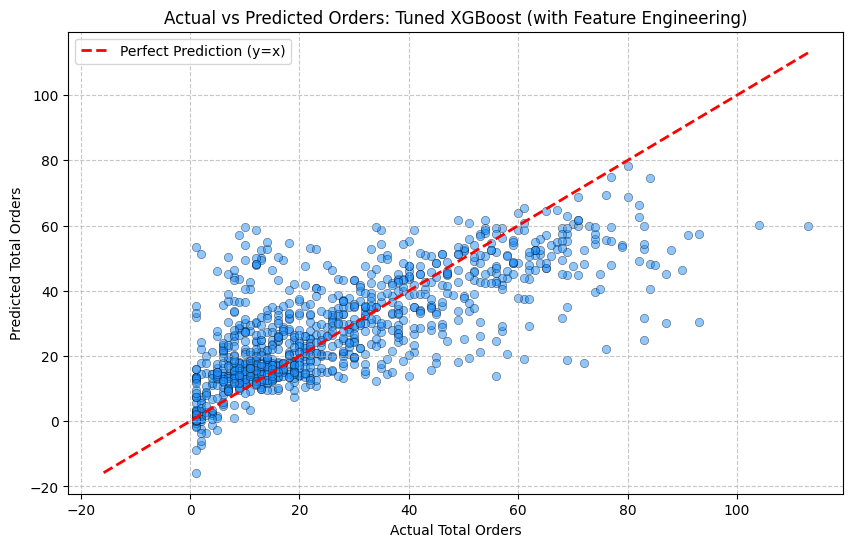

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set up the plot size
plt.figure(figsize=(10, 6))

# Create a scatter plot of Actual vs Predicted
sns.scatterplot(x=y_test_fe, y=fe_predictions, alpha=0.5, color='dodgerblue', edgecolor='k')

# Create a diagonal line representing perfect predictions
max_val = max(y_test_fe.max(), fe_predictions.max())
min_val = min(y_test_fe.min(), fe_predictions.min())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Perfect Prediction (y=x)')

# Add labels, title, and legend
plt.title('Actual vs Predicted Orders: Tuned XGBoost (with Feature Engineering)')
plt.xlabel('Actual Total Orders')
plt.ylabel('Predicted Total Orders')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### 6. High Epoch / Estimator Experiment (10,000 Trees)
Let's test what happens when we allow XGBoost to build up to 10,000 trees. We will use `early_stopping_rounds` to monitor the validation error and stop training if the model starts to overfit, preventing performance degradation on unseen data.

In [34]:
import time
from xgboost import XGBRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, r2_score

print("Setting up XGBoost for up to 10,000 trees (epochs)...")

# We need to manually apply the SimpleImputer first so we can pass the data into the eval_set
imputer = SimpleImputer(strategy='mean')
X_train_imputed = imputer.fit_transform(X_train_fe)
X_test_imputed = imputer.transform(X_test_fe)

# Initialize the model with 10,000 estimators and early stopping
xgb_10k = XGBRegressor(
    n_estimators=10000,
    max_depth=5,
    learning_rate=0.05, # A slightly lower learning rate works well with more trees
    random_state=42,
    early_stopping_rounds=50 # Stop if no improvement for 50 consecutive rounds
)

start_time = time.time()

# Fit the model and monitor performance on the test set
print("Training started. Watch the validation error:")
xgb_10k.fit(
    X_train_imputed, y_train_fe,
    eval_set=[(X_test_imputed, y_test_fe)],
    verbose=100 # Print output every 100 trees
)

end_time = time.time()

# Make predictions with the best iteration
pred_10k = xgb_10k.predict(X_test_imputed)

print(f"\nTraining completed in {end_time - start_time:.2f} seconds.")
print(f"XGBoost stopped early and found the best performance at tree #{xgb_10k.best_iteration}")

print("\n--- Performance Comparison ---")
print("Previous Best (Tuned XGBoost with 200 Trees):")
print(f"Model R-squared: {r2_score(y_test_fe, fe_predictions):.2f}")
print(f"Average Error: {mean_absolute_error(y_test_fe, fe_predictions):.2f} orders per hour\n")

print("New Model (Up to 10,000 Trees with Early Stopping):")
print(f"Model R-squared: {r2_score(y_test_fe, pred_10k):.2f}")
print(f"Average Error: {mean_absolute_error(y_test_fe, pred_10k):.2f} orders per hour")

Setting up XGBoost for up to 10,000 trees (epochs)...
Training started. Watch the validation error:
[0]	validation_0-rmse:21.22756
[100]	validation_0-rmse:15.42932
[200]	validation_0-rmse:15.08835
[300]	validation_0-rmse:14.76767
[400]	validation_0-rmse:14.66055
[500]	validation_0-rmse:14.54997
[600]	validation_0-rmse:14.46047
[700]	validation_0-rmse:14.40498
[800]	validation_0-rmse:14.38121
[857]	validation_0-rmse:14.39230

Training completed in 0.95 seconds.
XGBoost stopped early and found the best performance at tree #807

--- Performance Comparison ---
Previous Best (Tuned XGBoost with 200 Trees):
Model R-squared: 0.54
Average Error: 10.34 orders per hour

New Model (Up to 10,000 Trees with Early Stopping):
Model R-squared: 0.56
Average Error: 10.30 orders per hour
